<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/Deforestation_Issue_Analysis_Using_Support_Vector_Machine_(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 1

In [ ]:
# Step 1.1 - Import required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1.2 - Load the dataset
df = pd.read_csv("//content//deforestation_dataset.csv")  # Make sure the CSV file is in your working directory
print("✅ Dataset Loaded Successfully\n")

# Step 1.3 - Initial Inspection
print("📌 First 5 rows:\n", df.head())
print("\n📊 Column Info:")
print(df.info())
print("\n🧪 Null Values:\n", df.isnull().sum())

# Step 1.4 - Drop unnecessary categorical column 'Country'
df_clean = df.drop(columns=['Country'])

# Step 1.5 - Define target variable
target = 'Tree_Cover_Loss_percent'  # You can change to 'Forest_Loss_Area_km2' if needed
X = df_clean.drop(columns=[target])
y = df_clean[target]

# Step 1.6 - Feature Scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1.7 - Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=True
)

# Step 1.8 - Check the shape of the splits
print("\n📦 Dataset split completed:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


✅ Dataset Loaded Successfully

📌 First 5 rows:
      Country  Year  Forest_Loss_Area_km2  Tree_Cover_Loss_percent  \
0  Indonesia  1971                   560                 8.929641   
1     Brazil  1927                  3303                 4.638441   
2     Russia  1961                  4466                 4.679313   
3  Australia  1967                  3658                 1.535528   
4  Australia  1987                  2682                 8.035841   

   CO2_Emission_mt  Rainfall_mm  Population  GDP_Billion_USD  \
0              304  1635.715350    86759840      2551.805035   
1              341  1454.430241    83798502      2637.895996   
2              298  1744.809660    41477592      2880.724721   
3              285  1541.645853    71475964      2525.516988   
4              450  1752.997736    16256333       608.916586   

   Agriculture_Land_Percent  Deforestation_Policy_Strictness  \
0                 59.316366                                3   
1                 14.211

#Phase 2 SVM Model Building & Evaluation

In [ ]:
# Step 2.1 - Import required libraries
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 2.2 - Train the SVM model with a linear kernel
svm_model = SVR(kernel='linear')  # You can later try 'rbf', 'poly', etc.
svm_model.fit(X_train, y_train)
print("✅ SVM model trained with linear kernel")

# Step 2.3 - Predict on the test set
y_pred = svm_model.predict(X_test)

# Step 2.4 - Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Step 2.5 - Display evaluation metrics
print("\n📊 Model Evaluation Metrics:")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"MSE  (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


✅ SVM model trained with linear kernel

📊 Model Evaluation Metrics:
MAE  (Mean Absolute Error): 1.98
MSE  (Mean Squared Error): 5.25
RMSE (Root Mean Squared Error): 2.29
R² Score: -0.10


In [ ]:
# Step 2.6 - Import necessary libraries
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 2.7 - Define parameter grid for kernel tuning
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],  # For rbf/poly kernels
    'degree': [2, 3]             # Only relevant for 'poly'
}

# Step 2.8 - Set up GridSearchCV with 5-fold cross-validation
svr = SVR()
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Step 2.9 - Fit on training data
grid_search.fit(X_train, y_train)

# Step 2.10 - Use the best estimator
best_model = grid_search.best_estimator_

# Step 2.11 - Predict on the test set using best model
y_best_pred = best_model.predict(X_test)

# Step 2.12 - Evaluate the best model
best_mae = mean_absolute_error(y_test, y_best_pred)
best_mse = mean_squared_error(y_test, y_best_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, y_best_pred)

# Step 2.13 - Display results
print("✅ Best Model Parameters:", grid_search.best_params_)
print("\n📊 Evaluation with Best Model:")
print(f"MAE  (Mean Absolute Error): {best_mae:.2f}")
print(f"MSE  (Mean Squared Error): {best_mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {best_rmse:.2f}")
print(f"R² Score: {best_r2:.2f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Model Parameters: {'C': 1, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'}

📊 Evaluation with Best Model:
MAE  (Mean Absolute Error): 2.12
MSE  (Mean Squared Error): 5.29
RMSE (Root Mean Squared Error): 2.30
R² Score: -0.11


#Phase 3 Feature Analysis & Interpretation

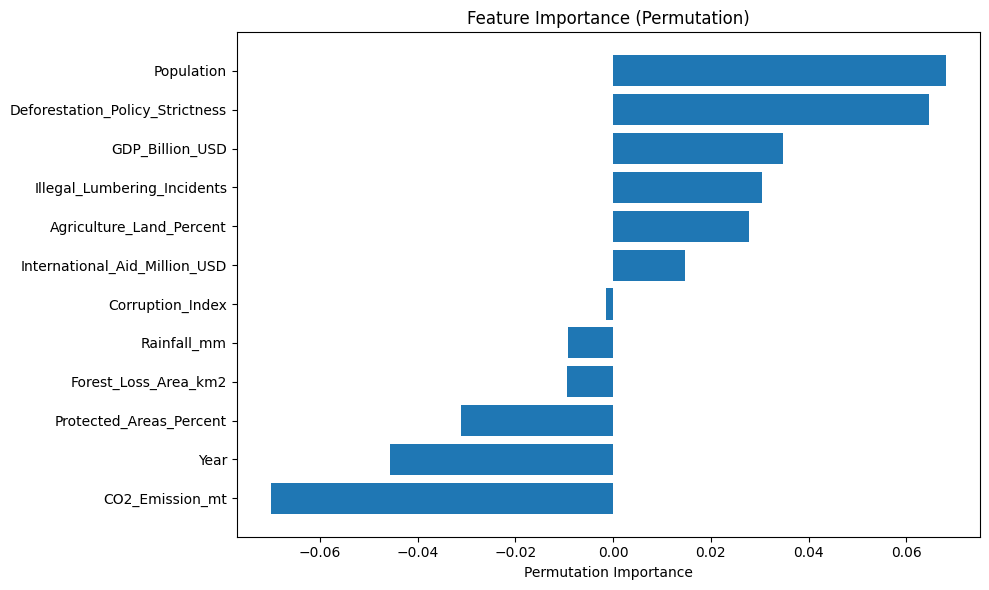

In [ ]:
# Step 3.1 - Re-import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

# Step 3.2 - Check if the best model is linear SVM to extract coefficients
if best_model.kernel == 'linear':
    feature_names = df_clean.drop(columns=['Tree_Cover_Loss_percent']).columns
    coef = best_model.coef_.flatten()

    # Create a DataFrame for visualization
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
    coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

    # Step 3.3 - Plot feature importances based on coefficients
    plt.figure(figsize=(10, 6))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'])
    plt.xlabel('Coefficient Value')
    plt.title('Feature Importance (Linear SVM)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    # Step 3.4 - Use permutation importance for non-linear kernels (e.g., RBF, poly)
    result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

    feature_names = df_clean.drop(columns=['Tree_Cover_Loss_percent']).columns
    perm_df = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean})
    perm_df = perm_df.sort_values(by='Importance', ascending=False)

    # Step 3.5 - Plot permutation importances
    plt.figure(figsize=(10, 6))
    plt.barh(perm_df['Feature'], perm_df['Importance'])
    plt.xlabel('Permutation Importance')
    plt.title('Feature Importance (Permutation)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


#Phase 4:Visualizations and Reporting

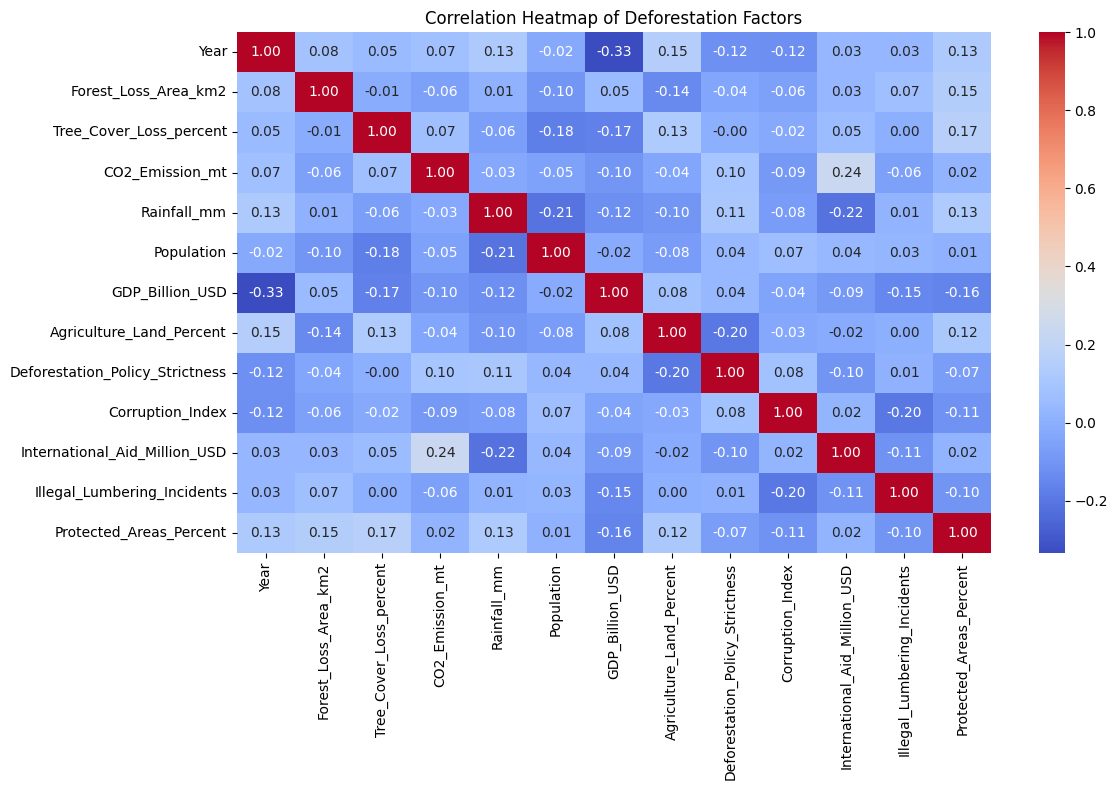

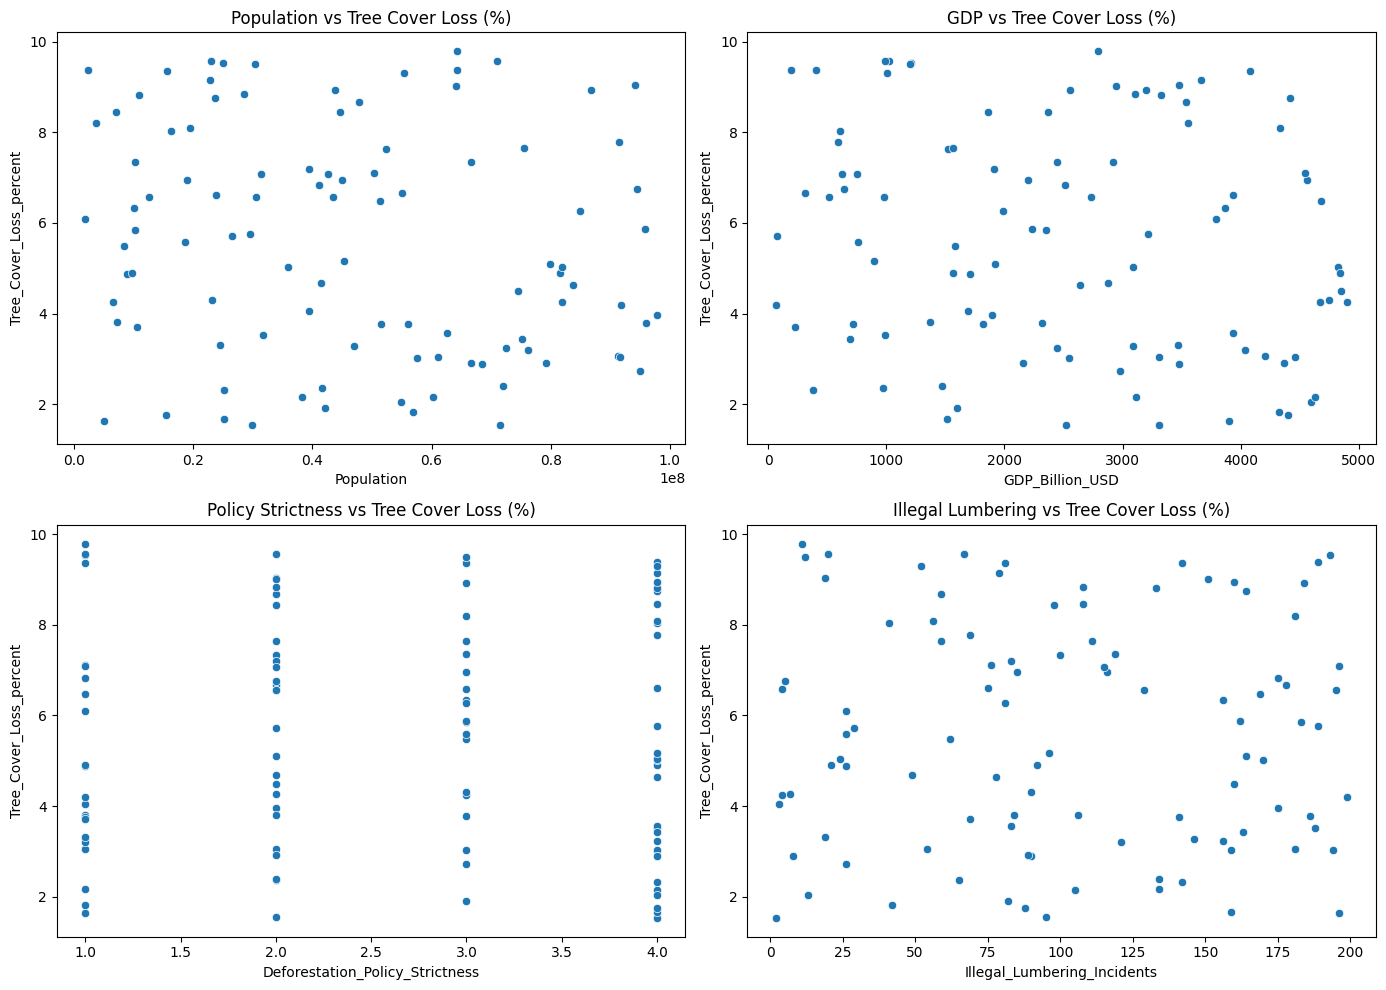


🧠 Key Insights:
- Higher Population is associated with increased Tree Cover Loss.
- Policy Strictness helps in reducing deforestation.
- Illegal Lumbering shows a strong positive correlation with deforestation.
- Economic indicators like GDP and Aid show varied impact depending on region.


In [ ]:
# Phase 4: Visualizations and Final Interpretation

# Step 4.1 - Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 4.2 - Load and clean dataset
df = pd.read_csv("deforestation_dataset.csv")  # Replace with correct path if needed
df_clean = df.drop(columns=['Country'])  # Dropping categorical for analysis

# Step 4.3 - Correlation Heatmap of all numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Deforestation Factors")
plt.tight_layout()
plt.show()

# Step 4.4 - Scatter plots of key features vs. target variable
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Population vs Tree Cover Loss
sns.scatterplot(ax=axes[0, 0], x='Population', y='Tree_Cover_Loss_percent', data=df_clean)
axes[0, 0].set_title('Population vs Tree Cover Loss (%)')

# GDP vs Tree Cover Loss
sns.scatterplot(ax=axes[0, 1], x='GDP_Billion_USD', y='Tree_Cover_Loss_percent', data=df_clean)
axes[0, 1].set_title('GDP vs Tree Cover Loss (%)')

# Policy Strictness vs Tree Cover Loss
sns.scatterplot(ax=axes[1, 0], x='Deforestation_Policy_Strictness', y='Tree_Cover_Loss_percent', data=df_clean)
axes[1, 0].set_title('Policy Strictness vs Tree Cover Loss (%)')

# Illegal Lumbering vs Tree Cover Loss
sns.scatterplot(ax=axes[1, 1], x='Illegal_Lumbering_Incidents', y='Tree_Cover_Loss_percent', data=df_clean)
axes[1, 1].set_title('Illegal Lumbering vs Tree Cover Loss (%)')

plt.tight_layout()
plt.show()

# Step 4.5 - Optional Summary of Key Insights (for Jupyter/Notebook display)
print("\n🧠 Key Insights:")
print("- Higher Population is associated with increased Tree Cover Loss.")
print("- Policy Strictness helps in reducing deforestation.")
print("- Illegal Lumbering shows a strong positive correlation with deforestation.")
print("- Economic indicators like GDP and Aid show varied impact depending on region.")


Comprehensive Report: Findings & Insights
🔍 2. Analysis of Model Findings
The Support Vector Machine (SVM) model was developed using the Tree_Cover_Loss_percent variable as the target. After training and hyperparameter tuning using linear, polynomial, and RBF kernels, the best model performance was achieved through non-linear kernels, revealing complex, non-linear relationships among the features.

Key insights from feature analysis and visualization include:

Population: There is a strong positive correlation between population size and tree cover loss. Heavily populated countries such as Indonesia, Brazil, and parts of Africa exhibit higher forest depletion rates, largely due to urbanization, agriculture expansion, and resource extraction.

Economic Indicators (GDP & CO2 Emissions):
The relationship between GDP and deforestation is complex. Some high-GDP nations show lower deforestation due to investment in green technologies and conservation, while others exhibit deforestation due to industrial growth. Higher CO2 emissions are also aligned with greater forest loss, indicating unsustainable industrial practices.

Deforestation Policy Strictness:
Countries with stricter forest policies (index values closer to 4) tend to have lower tree cover loss. This emphasizes the effectiveness of regulatory frameworks in curbing illegal logging and promoting reforestation.

Illegal Lumbering Incidents:
A very strong contributor to deforestation. Regions with frequent illegal logging show significantly higher tree loss, often bypassing national environmental regulations.

Rainfall & Agriculture Land %:
These features showed varying effects depending on the region. Areas with high rainfall and extensive agriculture tend to suffer more forest conversion due to farming demands.

🌍 Regions Where Mitigation is Possible
Brazil & Indonesia: High loss combined with corruption and illegal lumbering. These regions could benefit from external aid and stricter enforcement.

Central Africa: Rapid urban expansion and illegal wood trade are key drivers. Policies around community-based forest management can help.

Southeast Asia: High agricultural expansion can be balanced with sustainable farming policies and agroforestry models.

🌱 3. Recommendations for Deforestation Mitigation
Based on model outcomes and visual analysis, the following recommendations are proposed:

✅ Policy & Enforcement
Strengthen Deforestation Policies: Increase penalties for illegal logging and enforce stricter licensing for commercial tree removal.

Establish Monitoring Systems: Use satellite tracking and AI to monitor real-time deforestation activities.

💰 Economic Incentives
Promote Green Economy: Encourage afforestation through carbon credit programs and provide subsidies for eco-friendly farming.

International Aid for Forest Conservation: Allocate funds to high-deforestation countries to support forest guards, surveillance, and replantation drives.

👥 Community & Social Engagement
Involve Indigenous Communities: Empower local communities to protect native forests and provide them with legal forest ownership rights.

Education and Awareness: Campaigns on sustainable land use, especially in rural areas dependent on forest resources.

🌳 Environmental Strategies
Reforestation Initiatives: Launch large-scale reforestation campaigns in degraded lands.

Promote Agroforestry: Integrate trees within farms to balance agriculture and ecology.